In [ ]:
# CELL 1
import os
import numpy as np
import random
import tensorflow as tf
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from tensorflow import keras
from tensorflow.keras import layers
import re

# reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Reproducibility enabled")

# dataset root
CLEAN_ROOT = Path("cleaned_data_lstm")


Reproducibility enabled


In [ ]:
# CELL 2

# =========================================
# WINDOWING
# =========================================

FS = 50
WIN_LEN = 200
STRIDE = 100

print("Window length:", WIN_LEN)
print("Stride:", STRIDE)

def make_windows(X):

    T, F = X.shape

    # If trial is shorter than window, pad with zeros
    if T < WIN_LEN:
        w = np.zeros((WIN_LEN, F))
        w[:T] = X
        return w[None,:,:]

    windows = []

    for i in range(0, T - WIN_LEN + 1, STRIDE):
        windows.append(X[i:i+WIN_LEN])

    return np.array(windows)

Window length: 200
Stride: 100


In [ ]:
# CELL 3

POSTURES = sorted([p.name for p in CLEAN_ROOT.iterdir() if p.is_dir()])
LABEL_TO_ID = {p:i for i,p in enumerate(POSTURES)}

print("Postures:", POSTURES)
print("Number of classes:", len(POSTURES))

SUBJECT_RE = re.compile(r"Sub_(\d+)_Trial_(\d+)\.csv")

rows = []

for posture in POSTURES:

    for f in (CLEAN_ROOT/posture).glob("*.csv"):

        m = SUBJECT_RE.search(f.name)

        if m:

            rows.append({
                "path": f,
                "posture": posture,
                "label": LABEL_TO_ID[posture],
                "subject": int(m.group(1)),
                "trial": int(m.group(2))
            })

df_items = pd.DataFrame(rows)

print("Total cleaned files:", len(df_items))
print("Subjects:", df_items["subject"].nunique())
print("Trials:", df_items["trial"].nunique())

Postures: ['1', '2', '3', '4', '5', '6']
Number of classes: 6
Total cleaned files: 828
Subjects: 46
Trials: 18


In [ ]:
# CELL 4

# =========================================
# CREATE WINDOW DATASET (ACC + EULER ONLY)
# =========================================

X_all = []
y_all = []
subj_all = []
trial_all = []

window_counter = 0

def select_acc_euler(X):
    """
    Input: (T, 60)
    Output: (T, 24)  -> 4 sensors × (acc(3) + euler(3))
    """

    selected = []

    for i in range(4):

        start = i * 15

        acc   = X[:, start + 0 : start + 3]
        euler = X[:, start + 12 : start + 15]

        selected.append(acc)
        selected.append(euler)

    return np.concatenate(selected, axis=1)


for _, row in df_items.iterrows():

    X = pd.read_csv(row["path"]).values

    # keep only acc + euler
    X = select_acc_euler(X)

    windows = make_windows(X)

    for w in windows:

        X_all.append(w)
        y_all.append(row["label"])
        subj_all.append(row["subject"])
        trial_all.append(row["trial"])

    window_counter += len(windows)


X_all = np.array(X_all)
y_all = np.array(y_all)
subj_all = np.array(subj_all)
trial_all = np.array(trial_all)

print("\n===== DATASET SUMMARY =====")

print("Total windows:", window_counter)
print("X shape:", X_all.shape)
print("Features per timestep:", X_all.shape[2])


===== DATASET SUMMARY =====
Total windows: 11549
X shape: (11549, 200, 24)
Features per timestep: 24


In [ ]:
# CELL 5

# =========================================
# SUBJECT SPLIT
# =========================================

EXCLUDED_SUBJECTS = [29]

subjects = sorted(
    s for s in np.unique(subj_all)
    if s not in EXCLUDED_SUBJECTS
)

print("Remaining subjects:", subjects)

train_subj, temp_subj = train_test_split(
    subjects,
    test_size=0.30,
    random_state=SEED
)

val_subj, test_subj = train_test_split(
    temp_subj,
    test_size=0.50,
    random_state=SEED
)

print("Train subjects:", train_subj)
print("Val subjects:", val_subj)
print("Test subjects:", test_subj)


# =========================================
# CREATE MASKS
# =========================================

train_mask = np.isin(subj_all, train_subj)
val_mask   = np.isin(subj_all, val_subj)
test_mask  = np.isin(subj_all, test_subj)


# =========================================
# SPLIT DATA
# =========================================

X_train = X_all[train_mask]
X_val   = X_all[val_mask]
X_test  = X_all[test_mask]

y_train = y_all[train_mask]
y_val   = y_all[val_mask]
y_test  = y_all[test_mask]

print("\nDataset shapes")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


# =========================================
# ONE HOT ENCODE LABELS
# =========================================

y_train = keras.utils.to_categorical(y_train, num_classes=len(POSTURES))
y_val   = keras.utils.to_categorical(y_val,   num_classes=len(POSTURES))
y_test  = keras.utils.to_categorical(y_test,  num_classes=len(POSTURES))

print("\nLabel shapes")
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Remaining subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]
Train subjects: [18, 14, 44, 16, 10, 17, 39, 33, 28, 1, 32, 31, 6, 12, 35, 2, 42, 22, 3, 36, 24, 38, 11, 23, 19, 46, 21, 8, 15, 30, 40]
Val subjects: [26, 20, 37, 13, 7, 45, 5]
Test subjects: [4, 25, 41, 34, 43, 9, 27]

Dataset shapes
Train: (7774, 200, 24)
Val: (1761, 200, 24)
Test: (1762, 200, 24)

Label shapes
y_train: (7774, 6)
y_val: (1761, 6)
y_test: (1762, 6)


In [ ]:
# CELL 6

# =========================================
# PER SENSOR NORMALIZATION
# =========================================

# SENSOR_SLICES = [
#     slice(0,15),
#     slice(15,30),
#     slice(30,45),
#     slice(45,60)
# ]
SENSOR_SLICES = [
    slice(0,6),
    slice(6,12),
    slice(12,18),
    slice(18,24)
]

def compute_sensor_norm(X):

    means = []
    stds  = []

    for s in SENSOR_SLICES:

        flat = X[:,:,s].reshape(-1,6)

        mean = flat.mean(axis=0, keepdims=True)
        std  = flat.std(axis=0, keepdims=True) + 1e-8

        means.append(mean)
        stds.append(std)

    return means, stds


def apply_sensor_norm(X, means, stds):

    Xn = X.copy()

    for s, mean, std in zip(SENSOR_SLICES, means, stds):

        Xn[:,:,s] = (X[:,:,s] - mean) / std

    return Xn


means, stds = compute_sensor_norm(X_train)

X_train = apply_sensor_norm(X_train, means, stds)
X_val   = apply_sensor_norm(X_val, means, stds)
X_test  = apply_sensor_norm(X_test, means, stds)

print("Normalization applied")
print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Normalization applied
Train shape: (7774, 200, 24)
Val shape: (1761, 200, 24)
Test shape: (1762, 200, 24)


In [7]:
# cell 7 
class SensorDropout(layers.Layer):

    def __init__(self,drop_prob=0.2):
        super().__init__()
        self.drop_prob = drop_prob

    def call(self,x,training=None):

        if not training:
            return x

        batch=tf.shape(x)[0]

        mask=tf.ones((batch,4,1),dtype=x.dtype)

        drop=tf.cast(
            tf.random.uniform((batch,4,1))>self.drop_prob,
            x.dtype
        )

        mask = mask*drop

        mask=tf.repeat(mask,repeats=15,axis=2)

        mask=tf.reshape(mask,(batch,1,60))

        return x*mask

In [ ]:
# CELL 8

# =========================================
# MODEL WITH SENSOR ATTENTION + BiLSTM + AVG POOL
# =========================================

def build_model(input_shape):

    inp = keras.Input(shape=input_shape)

    print("Model input:", input_shape)

    x = inp   

    # ---------------------------------
    # Split sensors
    # ---------------------------------

    # L5  = layers.Lambda(lambda x: x[:,:,0:15])(x)
    # T4  = layers.Lambda(lambda x: x[:,:,15:30])(x)
    # C7  = layers.Lambda(lambda x: x[:,:,30:45])(x)
    # T12 = layers.Lambda(lambda x: x[:,:,45:60])(x)
    L5  = layers.Lambda(lambda x: x[:,:,0:6])(x)
    T4  = layers.Lambda(lambda x: x[:,:,6:12])(x)
    C7  = layers.Lambda(lambda x: x[:,:,12:18])(x)
    T12 = layers.Lambda(lambda x: x[:,:,18:24])(x)

    print("Sensor feature size:", 6)

    # ---------------------------------
    # Sensor CNN block
    # ---------------------------------

    def sensor_block(x):

        x = layers.Conv1D(
            filters=32,
            kernel_size=5,
            padding="same",
            activation="relu"
        )(x)

        x = layers.BatchNormalization()(x)

        x = layers.Conv1D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="relu"
        )(x)

        x = layers.BatchNormalization()(x)

        # Feature attention
        attention = layers.Dense(x.shape[-1], activation="tanh")(x)
        attention = layers.Softmax(axis=-1)(attention)

        x = layers.Multiply()([x, attention])

        return x


    L5  = sensor_block(L5)
    T4  = sensor_block(T4)
    C7  = sensor_block(C7)
    T12 = sensor_block(T12)

    # ---------------------------------
    # Stack sensors
    # ---------------------------------

    sensors = layers.Lambda(
        lambda x: tf.stack(x, axis=2)
    )([L5, T4, C7, T12])


    # ---------------------------------
    # Sensor attention
    # ---------------------------------

    attention = layers.Dense(1, activation="tanh")(sensors)
    attention = layers.Softmax(axis=2)(attention)

    sensors = layers.Multiply()([sensors, attention])

    fused = layers.Lambda(
        lambda x: tf.reduce_sum(x, axis=2)
    )(sensors)


    # ---------------------------------
    # TEMPORAL POOLING
    # ---------------------------------

    x = layers.GlobalAveragePooling1D()(fused)


    # ---------------------------------
    # CLASSIFIER
    # ---------------------------------

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(
        len(POSTURES),
        activation="softmax"
    )(x)


    model = keras.Model(inp, out)


    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=0.05
        ),
        metrics=["accuracy"]
    )

    model.summary()

    return model

In [ ]:
# CELL 9

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
# CELL 10

model = build_model(X_train.shape[1:])

early = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early, lr_scheduler],
    verbose=1
)


Model input: (200, 24)
Sensor feature size: 6
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 200, 24)]            0         []                            
                                                                                                  
 lambda (Lambda)             (None, 200, 6)               0         ['input_1[0][0]']             
                                                                                                  
 lambda_1 (Lambda)           (None, 200, 6)               0         ['input_1[0][0]']             
                                                                                                  
 lambda_2 (Lambda)           (None, 200, 6)               0         ['input_1[0][0]']             
                                               

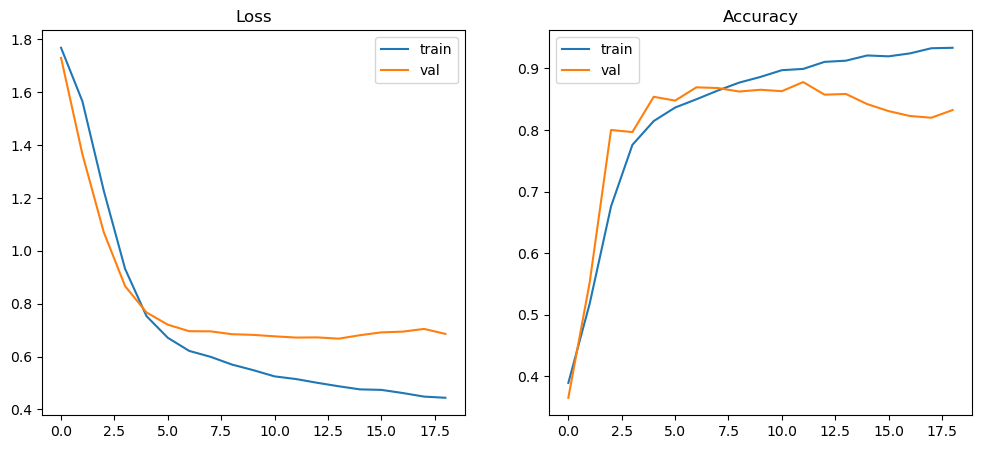

In [ ]:
# CELL 11

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(hist.history["loss"],label="train")
plt.plot(hist.history["val_loss"],label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist.history["accuracy"],label="train")
plt.plot(hist.history["val_accuracy"],label="val")
plt.title("Accuracy")
plt.legend()

plt.show()


===== WINDOW RESULTS =====
Window accuracy: 0.9080590238365494

Classification Report (Window)
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       294
           2       0.95      0.95      0.95       294
           3       0.74      0.91      0.82       294
           4       0.87      0.89      0.88       294
           5       0.95      0.94      0.95       294
           6       1.00      0.75      0.86       292

    accuracy                           0.91      1762
   macro avg       0.92      0.91      0.91      1762
weighted avg       0.92      0.91      0.91      1762



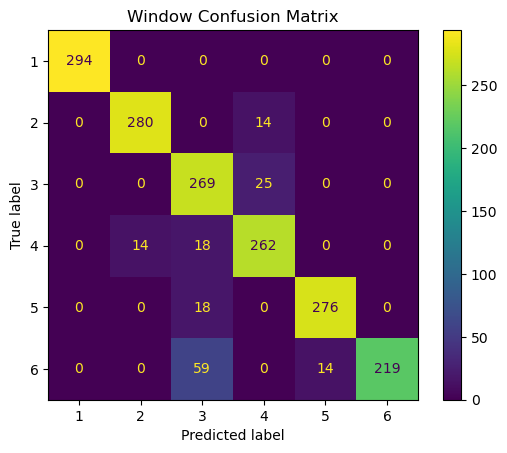

In [ ]:
# CELL 12

# =========================================
# WINDOW LEVEL EVALUATION
# =========================================

probs = model.predict(X_test, verbose=0)

y_pred = np.argmax(probs, axis=1)
y_true = np.argmax(y_test, axis=1)

window_acc = np.mean(y_pred == y_true)

print("\n===== WINDOW RESULTS =====")
print("Window accuracy:", window_acc)

print("\nClassification Report (Window)")

print(classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(POSTURES)),
    target_names=POSTURES,
    zero_division=0
))

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(POSTURES))
)

ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()

plt.title("Window Confusion Matrix")
plt.show()


===== TRIAL RESULTS =====
Trial accuracy: 0.9047619047619048

Classification Report (Trial)
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        21
           2       0.95      0.95      0.95        21
           3       0.73      0.90      0.81        21
           4       0.86      0.90      0.88        21
           5       0.95      0.90      0.93        21
           6       1.00      0.76      0.86        21

    accuracy                           0.90       126
   macro avg       0.92      0.90      0.91       126
weighted avg       0.92      0.90      0.91       126



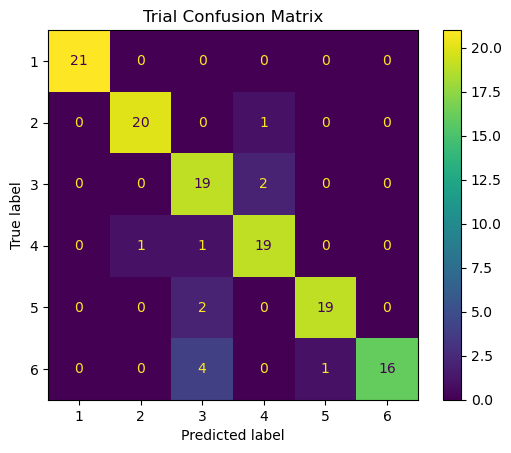

In [ ]:
# CELL 13

from collections import defaultdict

# =========================================
# TRIAL LEVEL EVALUATION
# =========================================

trial_probs = defaultdict(list)
trial_true = {}

test_subjects = subj_all[test_mask]
test_trials = trial_all[test_mask]

for p,true,s,t in zip(probs, y_true, test_subjects, test_trials):

    key = (s,t)   # subject + trial

    trial_probs[key].append(p)
    trial_true[key] = true


trial_pred = []
trial_true_list = []
trial_subjects = []

for k in trial_probs:

    w = np.array(trial_probs[k])

    summed = np.sum(np.log(w + 1e-8), axis=0)

    pred = np.argmax(summed)

    trial_pred.append(pred)
    trial_true_list.append(trial_true[k])
    trial_subjects.append(k[0])   # store subject id


trial_pred = np.array(trial_pred)
trial_true_list = np.array(trial_true_list)
trial_subjects = np.array(trial_subjects)

trial_acc = np.mean(trial_pred == trial_true_list)

print("\n===== TRIAL RESULTS =====")
print("Trial accuracy:", trial_acc)

print("\nClassification Report (Trial)")

print(classification_report(
    trial_true_list,
    trial_pred,
    labels=np.arange(len(POSTURES)),
    target_names=POSTURES,
    zero_division=0
))

cm = confusion_matrix(
    trial_true_list,
    trial_pred,
    labels=np.arange(len(POSTURES))
)

ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()

plt.title("Trial Confusion Matrix")
plt.show()


===== SUBJECT-POSTURE RESULTS =====
Subject/Posture accuracy: 0.9523809523809523

Classification Report (Subject/Posture)
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         7
           3       0.78      1.00      0.88         7
           4       1.00      1.00      1.00         7
           5       1.00      0.86      0.92         7
           6       1.00      0.86      0.92         7

    accuracy                           0.95        42
   macro avg       0.96      0.95      0.95        42
weighted avg       0.96      0.95      0.95        42



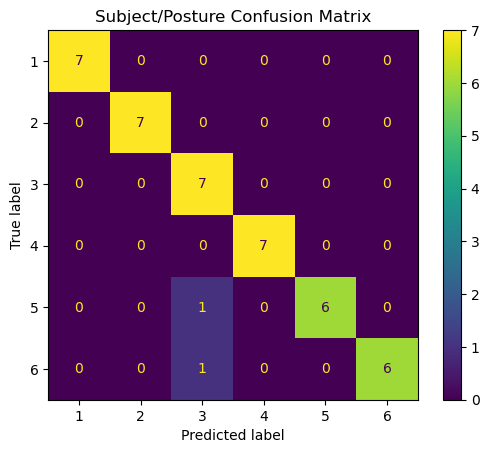

In [ ]:
# CELL 14

# =========================================
# SUBJECT-POSTURE LEVEL EVALUATION
# =========================================

subject_posture_votes = defaultdict(list)
subject_posture_true = {}

for pred,true,s in zip(trial_pred, trial_true_list, trial_subjects):

    key = (s,true)   # subject + posture

    subject_posture_votes[key].append(pred)
    subject_posture_true[key] = true


subject_pred = []
subject_true_list = []

for k in subject_posture_votes:

    votes = np.array(subject_posture_votes[k])

    pred = np.bincount(votes).argmax()

    subject_pred.append(pred)
    subject_true_list.append(subject_posture_true[k])


subject_pred = np.array(subject_pred)
subject_true_list = np.array(subject_true_list)

subject_acc = np.mean(subject_pred == subject_true_list)

print("\n===== SUBJECT-POSTURE RESULTS =====")
print("Subject/Posture accuracy:", subject_acc)

print("\nClassification Report (Subject/Posture)")

print(classification_report(
    subject_true_list,
    subject_pred,
    labels=np.arange(len(POSTURES)),
    target_names=POSTURES,
    zero_division=0
))

cm = confusion_matrix(
    subject_true_list,
    subject_pred,
    labels=np.arange(len(POSTURES))
)

ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()

plt.title("Subject/Posture Confusion Matrix")
plt.show()